In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
 
df= pd.read_csv(r'c:\Users\ayubi\Downloads\ml-assessment-ayush-kumar\data\q2_customers.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe().round(2))

Dataset Shape: (500, 6)

First 5 Rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Data Types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing Values:
age                         0
annual_spend                0
visi

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
 
print("\nScaled feature matrix (first 5 rows):")
print(X_scaled_df.head().round(4))


Scaled feature matrix (first 5 rows):
      age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0 -0.7252       -0.1762            0.1102      -0.2650                -0.0900   
1 -1.4885       -1.0468            0.4862      -0.9805                -0.8352   
2  0.1768        0.2673           -0.4538      -0.2369                -0.6740   
3 -0.7252       -1.0123            0.2982      -0.8278                -0.9963   
4 -1.4885       -1.0345            1.4261      -1.0060                -0.6539   

   num_categories_purchased  
0                    0.5510  
1                   -0.6807  
2                   -0.2701  
3                   -1.0912  
4                   -1.5018  


# ### Why Scaling is Essential Before Applying K-Means
# K-Means clustering computes **Euclidean distances** between data points and cluster centroids.
# Without scaling, features with large numeric ranges (e.g., `annual_spend` in the tens of thousands) will dominate the distance calculation over features with small ranges (e.g., `visits_per_month` which ranges from 1–20). 
# This causes the algorithm to effectively ignore low-range features, producing clusters that reflect scale rather than true data structure.
#
# **StandardScaler** transforms each feature to zero mean and unit variance, ensuring every feature contributes equally to the distance metric, a prerequisite for meaningful K-Means results.

WCSS values for K = 1 to 10:
  K= 1  WCSS = 3000.00
  K= 2  WCSS = 968.99
  K= 3  WCSS = 561.25
  K= 4  WCSS = 444.93
  K= 5  WCSS = 402.37
  K= 6  WCSS = 370.39
  K= 7  WCSS = 346.95
  K= 8  WCSS = 319.90
  K= 9  WCSS = 303.28
  K=10  WCSS = 289.11


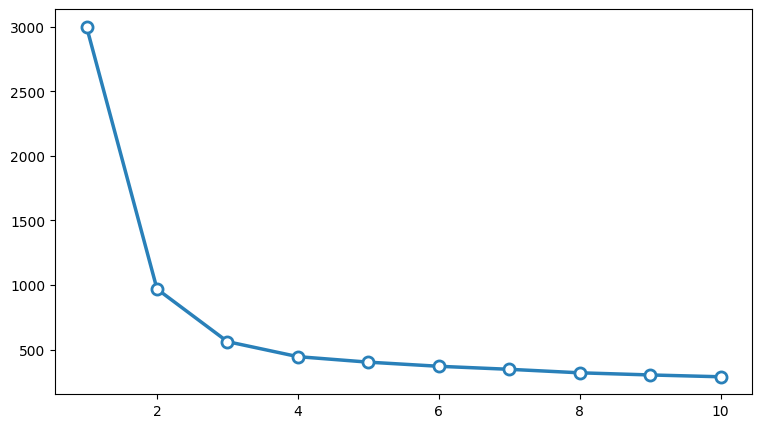

In [3]:
wcss = []
K_range = range(1, 11)
 
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
 
print("WCSS values for K = 1 to 10:")
for k, w in zip(K_range, wcss):
    print(f"  K={k:2d}  WCSS = {w:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, wcss, 'o-', color='#2980b9', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2)